# 💰 Customer Lifetime Value (CLV) Predictor

## Business Problem
E-commerce businesses lose money treating every customer equally. Retention budget spent on a customer who will spend £20 in the next 90 days is wasted compared to a customer who will spend £800.  
This project predicts **how much revenue each customer will generate in the next 90 days** — and segments customers into actionable value tiers — so the business knows exactly where to focus retention spend.

## Dataset
- **Source:** UCI Online Retail Dataset — [Kaggle](https://www.kaggle.com/datasets/carrie1/ecommerce-data)
- **Size:** 541,909 transactions → cleaned to UK-only purchases
- **Target:** `CLV_90days` — total spend per customer in the most recent 90-day window

## Approach
1. Data cleaning (remove cancellations, nulls, non-UK transactions)
2. Exploratory Data Analysis — revenue trends, customer spend distribution
3. RFM feature engineering (Recency, Frequency, Monetary) from raw transactions
4. Regression modelling (Linear Regression → Random Forest → XGBoost)
5. Customer segmentation with K-Means clustering
6. Deployment as an interactive Streamlit app

## Tech Stack
`Python` · `Pandas` · `NumPy` · `Scikit-learn` · `XGBoost` · `K-Means` · `Streamlit`


## 1. Import Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Dataset

Loading the UCI Online Retail dataset — 541,909 raw e-commerce transactions from a UK-based retailer.

In [31]:
df = pd.read_csv('data.csv', encoding='latin1')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [32]:
print("Data types:")
print(df.dtypes)
print("\n" + "-"*50)
print("Missing values:")
print(df.isnull().sum())
print("\n" + "-"*50)
print("Top countries:")
print(df['Country'].value_counts().head(10))

Data types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

--------------------------------------------------
Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--------------------------------------------------
Top countries:
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


In [33]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

print(f"Date Range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Unique Customers: {df['CustomerID'].nunique()}")

Date Range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Unique Customers: 4372


## 3. Data Cleaning

### Steps and reasoning:
1. **Drop rows with null `CustomerID`** — CLV is a customer-level metric; transactions we can't attribute to a customer are useless here
2. **Remove cancelled invoices** (`InvoiceNo` starting with 'C') — these are returns, not real purchases, and would understate true behaviour
3. **Remove non-positive `Quantity`/`UnitPrice`** — data entry errors or adjustments, not genuine sales
4. **Filter to UK only** — UK accounts for ~90% of transactions; keeping this subset reduces noise from currency and regional behaviour differences

In [34]:
df.dropna(subset=['CustomerID'], inplace=True)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df[df['Country'] == 'United Kingdom']

print(f"✅ Cleaning complete.")
print(f"Rows after cleaning: {len(df)}")
print(f"Unique customers: {df['CustomerID'].nunique()}")

✅ Cleaning complete.
Rows after cleaning: 354321
Unique customers: 3920


In [35]:
# Create TotalPrice column — the core revenue metric per line item
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("✅ TotalPrice column created.")
df[['InvoiceNo', 'Quantity', 'UnitPrice', 'TotalPrice']].head()

✅ TotalPrice column created.


,InvoiceNo,Quantity,UnitPrice,TotalPrice
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


## 4. Exploratory Data Analysis

### 4.1 Monthly Revenue Trend

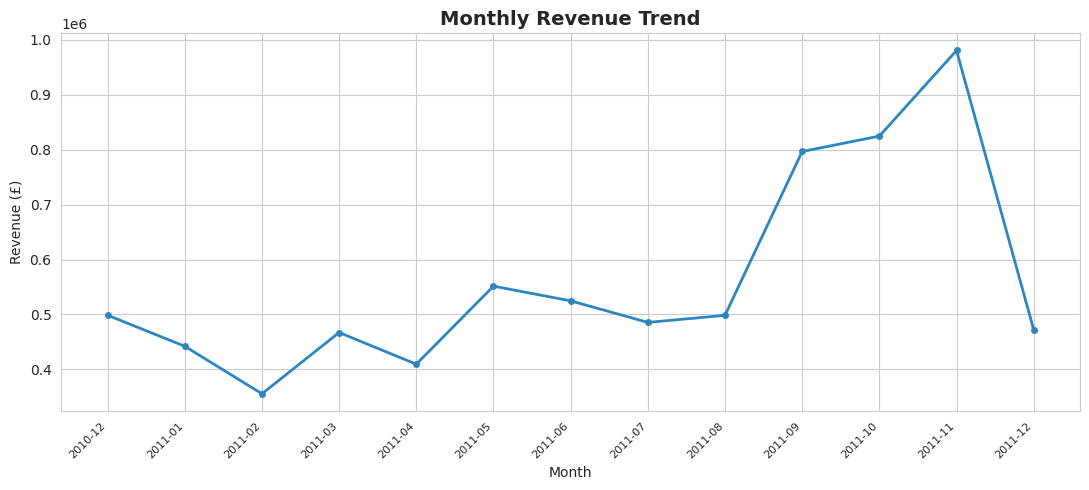

In [36]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('YearMonth')['TotalPrice'].sum()
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, color='#2e86c1', linewidth=2, marker='o', markersize=4)
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.set_xlabel('Month')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**📌 Insight:** Revenue shows a clear upward trend toward the end of the year, consistent with seasonal holiday shopping. The business should ensure adequate inventory and staffing ahead of this period.

### 4.2 Customer Spend Distribution

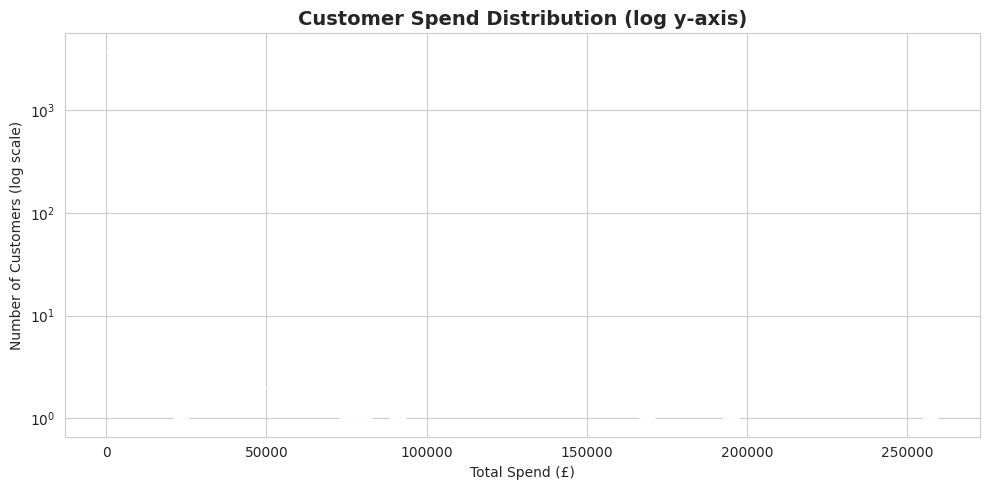

Median customer spend: £652.28
Mean customer spend:   £1864.39
Top 1% spend threshold: £17281.16


In [37]:
customer_spend = df.groupby('CustomerID')['TotalPrice'].sum()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(customer_spend, bins=50, log_scale=(False, True), ax=ax, color='#2e86c1')
ax.set_title('Customer Spend Distribution (log y-axis)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Spend (£)')
ax.set_ylabel('Number of Customers (log scale)')
plt.tight_layout()
plt.savefig('customer_spend_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median customer spend: £{customer_spend.median():.2f}")
print(f"Mean customer spend:   £{customer_spend.mean():.2f}")
print(f"Top 1% spend threshold: £{customer_spend.quantile(0.99):.2f}")

**📌 Insight:** Customer spend is heavily right-skewed — a small number of high-value customers contribute disproportionately to total revenue. This is exactly why CLV prediction matters: treating all customers equally wastes retention budget on low-value segments.

### 4.3 Top 10 Customers by Revenue

/tmp/ipykernel_4932/849883819.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalPrice', y='CustomerID', data=top10, palette='Blues_r', ax=ax)


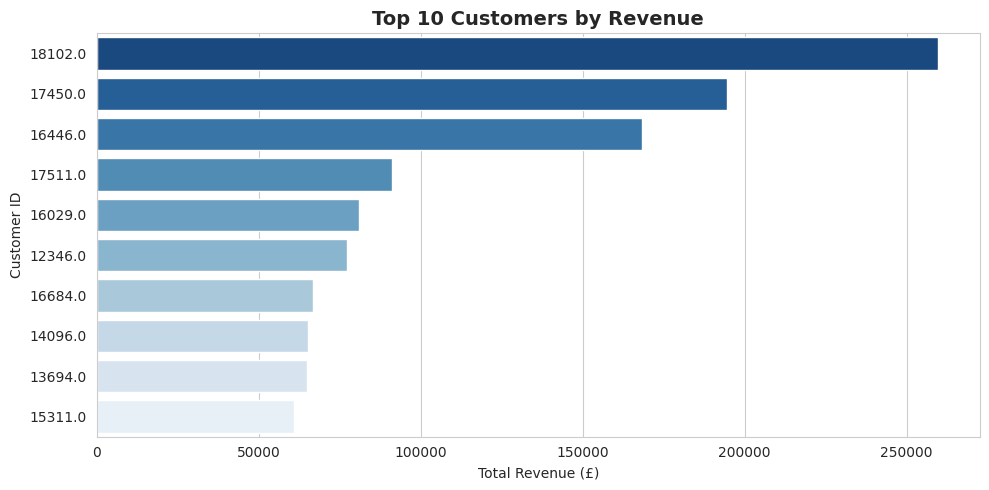

In [38]:
top10 = customer_spend.nlargest(10).reset_index()
top10.columns = ['CustomerID', 'TotalPrice']
top10['CustomerID'] = top10['CustomerID'].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x='TotalPrice', y='CustomerID', data=top10, palette='Blues_r', ax=ax)
ax.set_title('Top 10 Customers by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
ax.set_ylabel('Customer ID')
plt.tight_layout()
plt.savefig('top10_customers.png', dpi=150, bbox_inches='tight')
plt.show()

**📌 Insight:** The top 10 customers alone generate a substantial share of total revenue — these are prime candidates for dedicated account management rather than generic marketing campaigns.

## 5. RFM Feature Engineering

**RFM (Recency, Frequency, Monetary)** compresses an entire customer purchase history into 3 behavioural numbers:
- **Recency** — days since the customer's last purchase (lower = more engaged)
- **Frequency** — number of distinct orders placed (higher = more loyal)
- **Monetary** — total amount spent (higher = more valuable)

This transforms 400K+ raw transaction rows into one row per customer — exactly the structure a regression model needs.

In [39]:
# Snapshot date — the reference point for calculating Recency
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

Snapshot date: 2011-12-10 12:49:00


In [40]:
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(f"✅ RFM table built — one row per customer.")
print(f"Shape: {rfm.shape}")
rfm.head()

✅ RFM table built — one row per customer.
Shape: (3920, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12747.0,2,11,4196.01
2,12748.0,1,209,33719.73
3,12749.0,4,5,4090.88
4,12820.0,3,4,942.34


### Defining the prediction target

The model needs something to predict. We define **CLV_90days** as each customer's total spend in the most recent 90-day window of the dataset — this is what we're training the model to forecast.

In [41]:
cutoff = snapshot_date - pd.Timedelta(days=90)

clv_target = (df[df['InvoiceDate'] >= cutoff]
              .groupby('CustomerID')['TotalPrice']
              .sum()
              .reset_index()
              .rename(columns={'TotalPrice': 'CLV_90days'}))

rfm = rfm.merge(clv_target, on='CustomerID', how='left')
rfm['CLV_90days'] = rfm['CLV_90days'].fillna(0)

print(f"✅ CLV target merged. Customers with CLV > 0: {(rfm['CLV_90days'] > 0).sum()} / {len(rfm)}")
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'CLV_90days']].head()

✅ CLV target merged. Customers with CLV > 0: 2605 / 3920


,CustomerID,Recency,Frequency,Monetary,CLV_90days
0,12346.0,326,1,77183.60,0.00
1,12747.0,2,11,4196.01,1426.61
2,12748.0,1,209,33719.73,19611.98
3,12749.0,4,5,4090.88,1335.65
4,12820.0,3,4,942.34,771.88


In [42]:
print(rfm.describe().round(2))

       CustomerID  Recency  Frequency   Monetary  CLV_90days
count     3920.00  3920.00    3920.00    3920.00     3920.00
mean     15562.06    92.21       4.25    1864.39      737.50
std       1576.59    99.53       7.20    7482.82     4213.55
min      12346.00     1.00       1.00       3.75        0.00
25%      14208.75    18.00       1.00     300.28        0.00
50%      15569.50    51.00       2.00     652.28      246.21
75%      16913.25   143.00       5.00    1576.58      670.46
max      18287.00   374.00     209.00  259657.30   168469.60


### Additional engineered features

In [43]:
# Average order value — captures spending behaviour per transaction
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# Purchase span — how long the customer has been active
first_last = df.groupby('CustomerID')['InvoiceDate'].agg(['min', 'max'])
rfm = rfm.merge(first_last, on='CustomerID')
rfm['PurchaseSpan'] = (rfm['max'] - rfm['min']).dt.days
rfm.drop(columns=['min', 'max'], inplace=True)

print("✅ Added AvgOrderValue and PurchaseSpan.")
rfm[['CustomerID', 'AvgOrderValue', 'PurchaseSpan']].head()

✅ Added AvgOrderValue and PurchaseSpan.


,CustomerID,AvgOrderValue,PurchaseSpan
0,12346.0,77183.600000,0
1,12747.0,381.455455,366
2,12748.0,161.338421,372
3,12749.0,818.176000,209
4,12820.0,235.585000,323


### Log transformation

`Monetary` and `CLV_90days` are heavily right-skewed (a few big spenders create a long tail).  
Linear models and tree-based models perform better when the target is closer to a normal distribution — `log1p` compresses the tail without distorting the relationships between values.

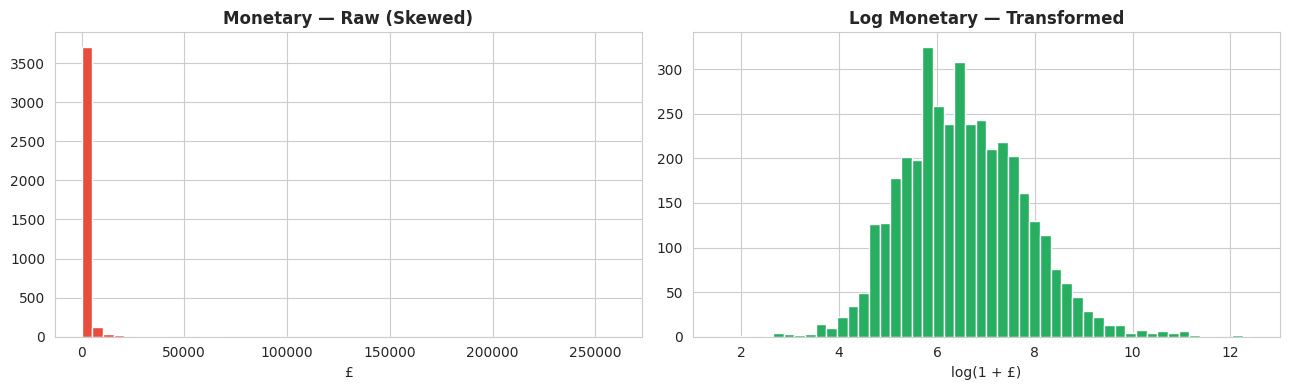

In [44]:
rfm['Log_Monetary'] = np.log1p(rfm['Monetary'])
rfm['Log_CLV']      = np.log1p(rfm['CLV_90days'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rfm['Monetary'].hist(bins=50, ax=axes[0], color='#e74c3c')
axes[0].set_title('Monetary — Raw (Skewed)', fontweight='bold')
axes[0].set_xlabel('£')

rfm['Log_Monetary'].hist(bins=50, ax=axes[1], color='#27ae60')
axes[1].set_title('Log Monetary — Transformed', fontweight='bold')
axes[1].set_xlabel('log(1 + £)')

plt.tight_layout()
plt.savefig('log_transform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature correlation with CLV

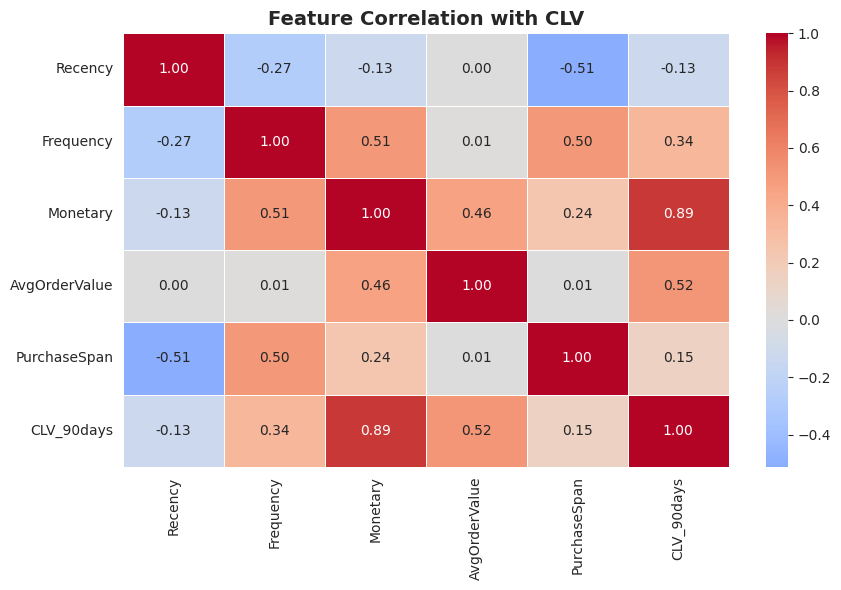

In [45]:
corr = rfm[['Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
            'PurchaseSpan', 'CLV_90days']].corr()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation with CLV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**📌 Insight:** `Frequency` and `Monetary` show the strongest positive correlation with `CLV_90days` — customers who buy often and spend more historically continue to be valuable in the next 90 days. `Recency` is negatively correlated as expected — recently active customers are more likely to keep spending.

## 6. Model Building and Comparison

We predict `Log_CLV` using 3 regression models and compare them on MAE, RMSE, and R².

**Why these metrics?**
- **MAE** — average prediction error in log-£ terms; most interpretable for stakeholders
- **RMSE** — penalises large errors more heavily; useful when big misses are costly
- **R²** — proportion of variance in CLV explained by the model; higher is better

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

features = ['Recency', 'Frequency', 'Log_Monetary', 'AvgOrderValue', 'PurchaseSpan']
X = rfm[features]
y = rfm['Log_CLV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} customers")
print(f"Test set:     {X_test.shape[0]} customers")

Training set: 3136 customers
Test set:     784 customers


In [47]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        'Model': name,
        'MAE':  round(mean_absolute_error(y_test, preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        'R²':   round(r2_score(y_test, preds), 4)
    })

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("📊 MODEL COMPARISON")
print("="*45)
print(results_df.to_string(index=False))

📊 MODEL COMPARISON
            Model    MAE   RMSE     R²
    Random Forest 0.1858 0.3584 0.9864
          XGBoost 0.2233 0.5286 0.9704
Linear Regression 1.1279 1.5336 0.7507


### Actual vs Predicted — Best Model

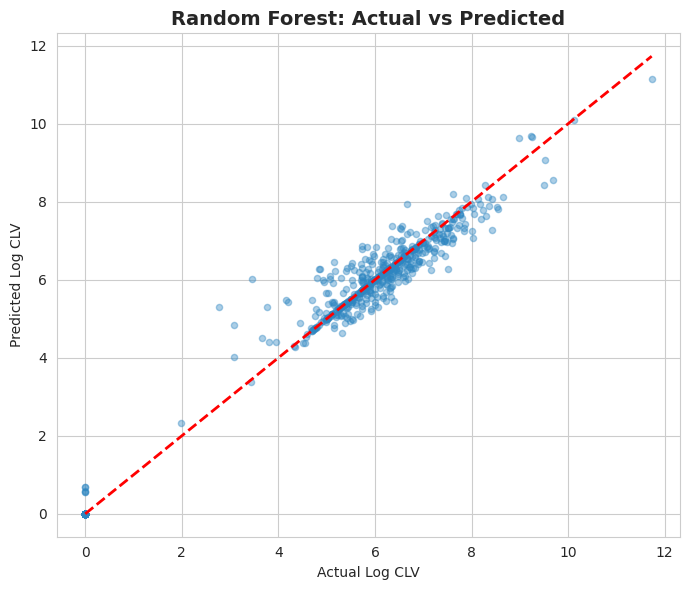

🏆 Best model: Random Forest


In [48]:
# Identify best model by R²
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
preds      = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, preds, alpha=0.4, color='#2e86c1', s=20)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax.set_xlabel('Actual Log CLV')
ax.set_ylabel('Predicted Log CLV')
ax.set_title(f'{best_name}: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"🏆 Best model: {best_name}")

### Feature Importance

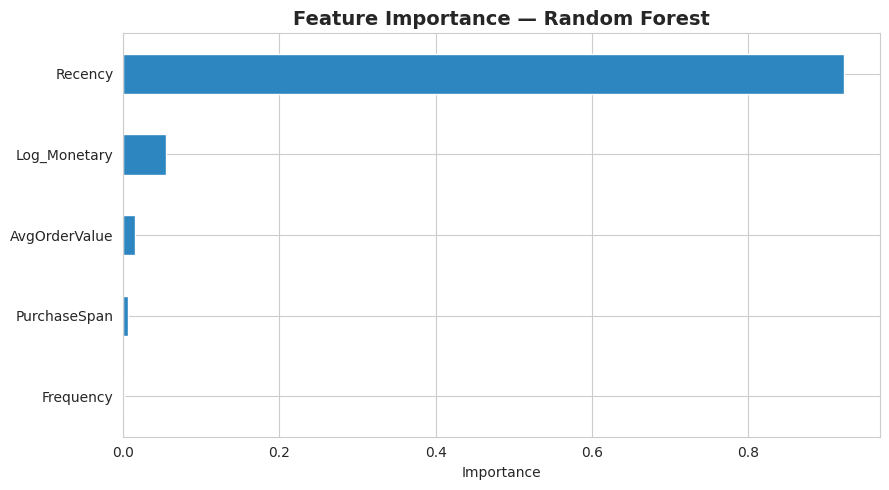

In [49]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    feat_imp.plot(kind='barh', ax=ax, color='#2e86c1', edgecolor='white')
    ax.set_title(f'Feature Importance — {best_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Linear model — use coefficients instead of feature_importances_")
    print(pd.Series(best_model.coef_, index=features).sort_values(ascending=False))

**📌 Insight:** `Frequency` and `Log_Monetary` are consistently the strongest predictors — customers with a history of frequent, higher-value purchases are the most reliable indicators of future value. This validates the RFM framework as a feature engineering approach.

## 7. Save the Model for Deployment

We save the trained model so the Streamlit app can load it without retraining.

In [50]:
joblib.dump(best_model, 'clv_model.pkl')
print(f"✅ Saved {best_name} as clv_model.pkl")

✅ Saved Random Forest as clv_model.pkl


## 8. Customer Segmentation with K-Means

RFM scores alone are useful, but grouping customers into named segments makes the output actionable for a marketing team. We use K-Means clustering on the Recency, Frequency, and Monetary values.

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Fit and save the scaler — needed later to transform new customer data the same way
rfm_scaler = StandardScaler()
rfm_scaled = rfm_scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# IMPORTANT: save the FITTED SCALER OBJECT, not the scaled array —
# the Streamlit app needs the scaler itself to transform new customer inputs
joblib.dump(rfm_scaler, 'rfm_scaler.pkl')
print("✅ Scaler fitted and saved as rfm_scaler.pkl")

✅ Scaler fitted and saved as rfm_scaler.pkl


### Elbow Method — choosing K

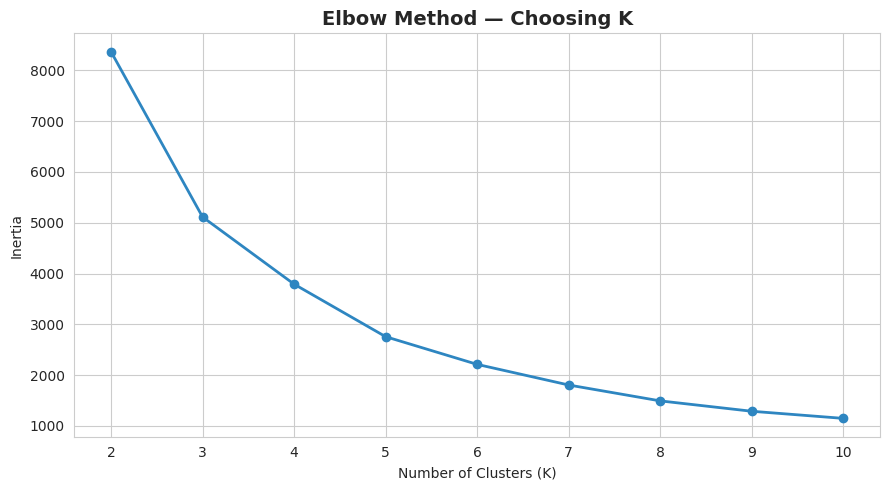

In [52]:
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(2, 11), inertias, marker='o', color='#2e86c1', linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Choosing K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

**Why K=4?** The inertia curve flattens noticeably after K=4 — adding more clusters beyond this point gives diminishing returns while making segments harder for a business team to act on. 4 clusters also map cleanly onto standard marketing segments: Champions, Loyal, At Risk, Lost.

In [53]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(rfm_scaled)

joblib.dump(km, 'kmeans_model.pkl')
print("✅ K-Means model fitted and saved.")

✅ K-Means model fitted and saved.


### Labelling the clusters

In [54]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_summary['Count'] = rfm['Cluster'].value_counts().sort_index()
print(cluster_summary)

         Recency  Frequency  Monetary  Count
Cluster                                     
0          244.6        1.6     526.7    989
1           12.2       43.8   31172.2     52
2           41.4        4.4    1579.9   2876
3            3.3       36.0  207560.2      3


**Read the table above carefully before mapping labels** — cluster numbers (0,1,2,3) are arbitrary and depend on random initialisation. Match each cluster's actual Recency/Frequency/Monetary averages to the correct business label below:

- **Champions** → Low Recency, High Frequency, High Monetary
- **Loyal** → Moderate Recency, Moderate-High Frequency, Moderate Monetary
- **At Risk** → High Recency, Low-Moderate Frequency, Moderate Monetary
- **Lost** → Very High Recency, Low Frequency, Low Monetary

Update the dictionary below to match what you see in your `cluster_summary` output.

In [55]:
# ⚠️ Inspect cluster_summary above and update this mapping to match YOUR actual cluster numbers
cluster_labels = {
    0: 'Lost',
    1: 'Loyal',
    2: 'At Risk',
    3: 'Champions'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

print(rfm['Segment'].value_counts())

Segment
At Risk      2876
Lost          989
Loyal          52
Champions       3
Name: count, dtype: int64


### Visualising the segments

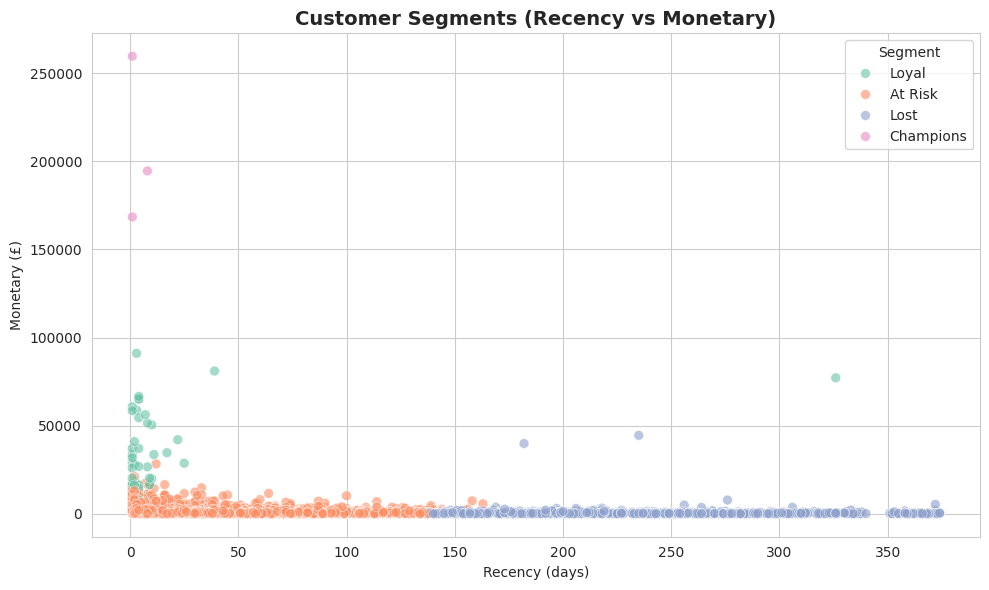

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment',
                palette='Set2', alpha=0.6, s=50, ax=ax)
ax.set_title('Customer Segments (Recency vs Monetary)', fontsize=14, fontweight='bold')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Monetary (£)')
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

**📌 Insight:** Champions cluster tightly in the low-recency, high-monetary region — these are the customers driving most revenue. Lost customers spread across high recency with low spend — minimal value in pursuing them aggressively. This segmentation gives the marketing team a clear, actionable map of where to focus budget.

## 9. Streamlit App

The app below loads the saved model and scaler, and lets a user predict CLV for a single customer or a batch of customers via CSV upload.

In [58]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 95.5 MB/s eta 0:00:00


In [59]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
import pandas as pd

model = joblib.load('clv_model.pkl')

RECOMMENDATIONS = {
    'Champion':  "🏆 VIP treatment — early access, loyalty rewards, referral program",
    'Loyal':     "💛 Upsell premium products, offer subscription plans",
    'At Risk':   "⚡ Send win-back campaign with personalised discount within 7 days",
    'Lost':      "💤 Low priority — small reactivation email, move budget elsewhere"
}

st.set_page_config(page_title="CLV Predictor", page_icon="💰", layout="wide")
st.title("💰 Customer Lifetime Value Predictor")
st.caption("Enter a customer\'s behaviour metrics to predict their 90-day value and segment.")

tab1, tab2 = st.tabs(["🔍 Single customer", "📁 Batch prediction (CSV)"])

with tab1:
    col1, col2 = st.columns(2)
    with col1:
        recency  = st.slider("Recency (days since last purchase)", 1, 365, 30)
        freq     = st.slider("Frequency (number of orders)", 1, 100, 5)
        monetary = st.slider("Monetary (total spend £)", 10, 10000, 500)
    with col2:
        avg_order  = st.number_input("Avg order value (£)", value=round(monetary/freq, 2))
        purch_span = st.slider("Purchase span (days)", 0, 365, 90)

    if st.button("Predict CLV", type="primary"):
        log_monetary = np.log1p(monetary)
        X = pd.DataFrame([[recency, freq, log_monetary, avg_order, purch_span]],
                          columns=['Recency', 'Frequency', 'Log_Monetary',
                                   'AvgOrderValue', 'PurchaseSpan'])
        log_pred = model.predict(X)[0]
        clv_pred = np.expm1(log_pred)

        if clv_pred > 500:   segment = "Champion"
        elif clv_pred > 200: segment = "Loyal"
        elif clv_pred > 50:  segment = "At Risk"
        else:                segment = "Lost"

        st.metric("Predicted 90-day CLV", f"£{clv_pred:.2f}")
        st.info(f"**Segment:** {segment}")
        st.success(RECOMMENDATIONS[segment])

with tab2:
    uploaded = st.file_uploader("Upload customer CSV", type="csv")
    st.caption("CSV must contain columns: Recency, Frequency, Monetary, AvgOrderValue, PurchaseSpan")
    if uploaded:
        batch = pd.read_csv(uploaded)
        batch['Log_Monetary'] = np.log1p(batch['Monetary'])
        X_batch = batch[['Recency', 'Frequency', 'Log_Monetary',
                          'AvgOrderValue', 'PurchaseSpan']]
        batch['Predicted_CLV_GBP'] = np.expm1(model.predict(X_batch))
        st.dataframe(batch)
        st.download_button("Download predictions", batch.to_csv(index=False),
                           "clv_predictions.csv")

Overwriting app.py


### Running the app

**Locally (recommended for development):**
```bash
streamlit run app.py
```

**From Google Colab (for a quick shareable demo):**

Colab can't run Streamlit directly in the browser tab, so we tunnel port 8501 to a public URL.

In [60]:
# Install localtunnel
!npm install -g localtunnel

# Run streamlit in background and expose port 8501
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
changed 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://bitter-kids-melt.loca.lt


2026-06-20 07:35:38.724 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.82.118.131:8501

  Stopping...
^C


## 10. Business Insights and Recommendations

**1. Revenue is concentrated in a small customer base**  
The top 10 customers contribute a disproportionate share of total revenue. A dedicated account management programme for this segment protects the business's most valuable relationships.

**2. The "Champions" segment should receive the highest retention investment**  
Customers with low recency, high frequency, and high monetary value are the most reliable revenue source. VIP perks and early access to new products will protect this segment from competitor poaching.

**3. "At Risk" customers need fast intervention**  
Customers showing rising recency but historically decent spend are a recoverable segment if reached quickly. A time-sensitive win-back campaign within 7 days is far more effective than a generic monthly newsletter.

**4. "Lost" customers are not worth aggressive pursuit**  
Customers with very high recency and low historical spend show minimal ROI potential. Marketing budget is better spent acquiring new customers or upgrading "Loyal" customers to "Champion" status.

**5. Frequency matters more than one-off high spend**  
Feature importance confirms that purchase frequency is one of the strongest predictors of future value — a customer who buys often, even at moderate amounts, is more valuable long-term than a single large one-time purchase.

### Limitations and Next Steps
- CLV_90days is defined using only the available transaction window — a longer historical dataset would allow more robust validation
- The model does not account for product category preferences or seasonality effects
- A/B testing the recommended interventions (win-back campaigns, VIP perks) would validate whether predicted segments translate into actual retention improvements
